<a href="https://colab.research.google.com/github/IntroComputationalPhysics-UNT/euler-and-solve-ivp-Ms091704/blob/main/Copy_of_scratchpad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## pseudo code for solving initial value/ termporal evolution systems

1. **import modules:** import math for simple functions and constants; import marplotlib.pyplot for plotting
2. **define the diff eq as a first order system** made a custom function from $\ddot{\theta} + \omega_0^2 sin(\theta)=0$ to give $\dot{\theta}= \omega$ amd $\dot{\omega} = - \omega_0^2 sin(\theta)$
3. **assign variables and time span**
4. **solve the diff eq**
5. **plot results and test output** plot the temporal evolution of theta and the phase portrait ('ang_vel' vs 'theta') define and compare with the analytic solution to the harmonic oscillator

In [9]:
import math
import matplotlib.pyplot as plt

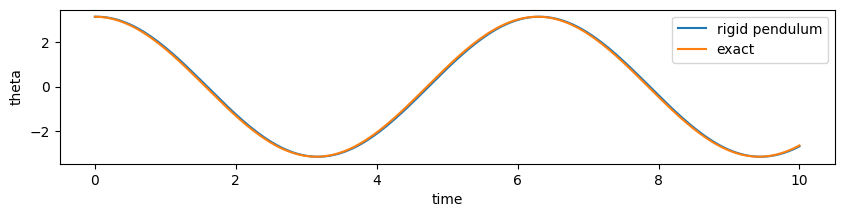

In [63]:
def euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0,t_f, n_steps):
  dt=(t_f-t_0)/n_steps #calc dt
  theta = [theta_0] #theta list
  ang_vel = [ang_vel_0] #angvel list
  t= [t_0] #time list
  for _ in range(n_steps):
    theta_new = theta[-1] + ang_vel[-1] *dt
    ang_vel_new = ang_vel[-1] - omega_0**2 * theta_new * dt
    t_new = t[-1] + dt
    theta.append(theta_new)
    ang_vel.append(ang_vel_new)
    t.append(t_new)
  return t, theta, ang_vel

#assign variables
omega_0 = 1
theta_0 = math.pi
ang_vel_0 = 0
t_0 = 0
t_f = 10
n_steps = 200

#solver
t, theta, ang_vel = euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0, t_f, n_steps)

#get exact values
theta_exact = [theta_0 * math.cos(omega_0 * (t[i]-t_0))+(ang_vel_0/omega_0)* math.sin(omega_0*(t[i]-t_0)) for i in range (len(t))]
ang_vel_exact=[-theta_0 * omega_0 * math.sin(omega_0 * (t[i]-t_0)) + ang_vel_0 *math.cos(omega_0 *(t[i]-t_0)) for i in range (len(t))]

#plot
plt.figure(figsize=(10, 2))
plt.plot(t, theta, label = 'rigid pendulum')
plt.plot(t, theta_exact, label = 'exact')
plt.xlabel('time')
plt.ylabel('theta')
plt.legend()
plt.show()

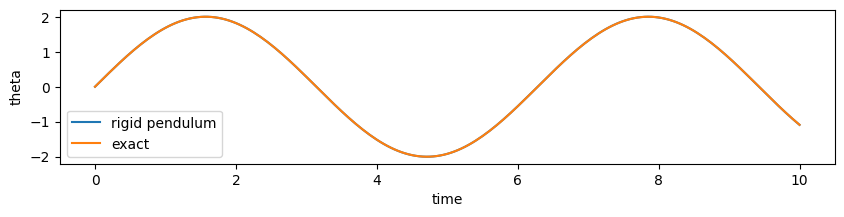

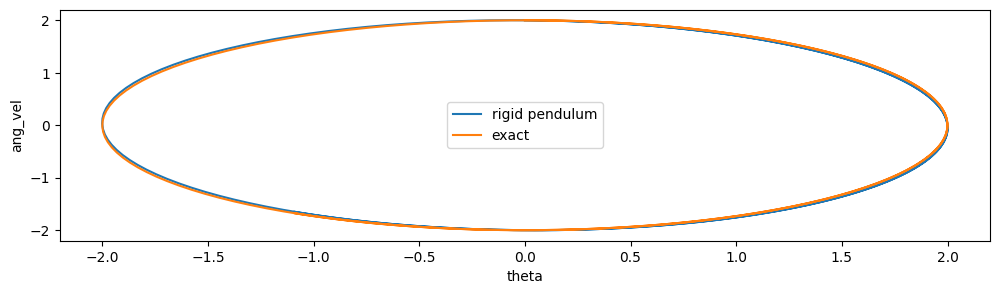

In [43]:

def euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0,t_f, n_steps):
  dt=(t_f-t_0)/n_steps #calc dt
  theta = [theta_0] #theta list
  ang_vel = [ang_vel_0] #angvel list
  t= [t_0] #time list
  for _ in range(n_steps):
    theta_new = theta[-1] + ang_vel[-1] *dt
    ang_vel_new = ang_vel[-1] - omega_0**2 * theta_new * dt
    t_new = t[-1] + dt
    theta.append(theta_new)
    ang_vel.append(ang_vel_new)
    t.append(t_new)
  return t, theta, ang_vel

#assign variables
omega_0 = 1
theta_0 = 0
ang_vel_0 = 2
t_0 = 0
t_f = 10
n_steps = 200

#solver
t, theta, ang_vel = euler_rigid_pendulum(omega_0, theta_0, ang_vel_0, t_0, t_f, n_steps)

#get exact values
theta_exact = [theta_0 * math.cos(omega_0 * (t[i]-t_0))+(ang_vel_0/omega_0)* math.sin(omega_0*(t[i]-t_0)) for i in range (len(t))]
ang_vel_exact=[-theta_0 * omega_0 * math.sin(omega_0 * (t[i]-t_0)) + ang_vel_0 *math.cos(omega_0 *(t[i]-t_0)) for i in range (len(t))]

#plot
plt.figure(figsize=(10, 2))
plt.plot(t, theta, label = 'rigid pendulum')
plt.plot(t, theta_exact, label = 'exact')
plt.xlabel('time')
plt.ylabel('theta')
plt.legend()

#phase portrait
plt.figure(figsize=(12, 3))
plt.plot(theta, ang_vel, label = 'rigid pendulum')
plt.plot(theta_exact, ang_vel_exact, label = 'exact')
plt.xlabel('theta')
plt.ylabel('ang_vel')
plt.legend()
plt.show()

###shows behavior more clearly over a longer period of time


## pseudo code to solve rigid pendulum system w numpy

1. **import modules:** import numpy as np and solve ivp from the integrate submodule
2. **define the diff eq as a first order system**
3. **assign variables and time span**
4. **solve the diff eq**
5. **plot results and test output** plot the temporal evolution of theta and the phase portrait

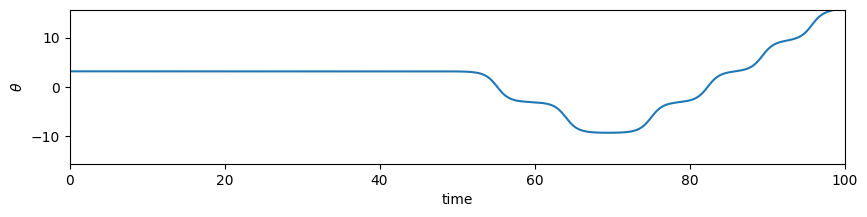

In [54]:
# import packages
import numpy as np # imports the `numpy` package and gives it an alias/name `np`
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp # imports the `solve_ivp` function from the `integrate` submodule of the `scipy` module

# define our differential equation
def rigid_pendulum_ode(t, y, omega_0=1):
 theta, ang_vel = y # unpacks y=[theta, ang_vel]
 dtheta_dt = ang_vel # define first derivative
 d2theta_dt2 = - omega_0 ** 2 * np.sin(theta) # define second derivative
 dy_dt = [dtheta_dt, d2theta_dt2] # define derivative of state variable
 return dy_dt

# Define the initial conditions, input parameters, and the time span
# initial conditions
theta_0 = math.pi
ang_vel_0 = 0
y_0 = [theta_0, ang_vel_0]

# input parameters
omega_0 = 1 # natural frequency

# time span
t_initial = 0
t_final = 100
t_span = [t_initial, t_final]

# solve differential equation
solution = solve_ivp(rigid_pendulum_ode, t_span, y_0, args=(omega_0,),dense_output=True)

# create list for plotting our solution
n_steps = 1000
t_plot = np.linspace(t_initial, t_final, n_steps)
theta_plot = solution.sol(t_plot)[0]
ang_vel_plot = solution.sol(t_plot)[1]

# plot the temporal evolution
plt.figure(figsize=(10,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.xlim([0, 100])
plt.ylim(- 5 * np.pi, 5 * np.pi)
plt.show()


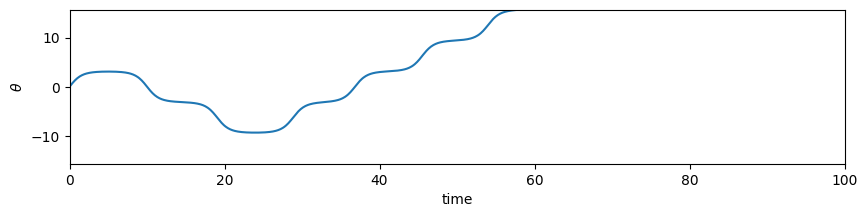

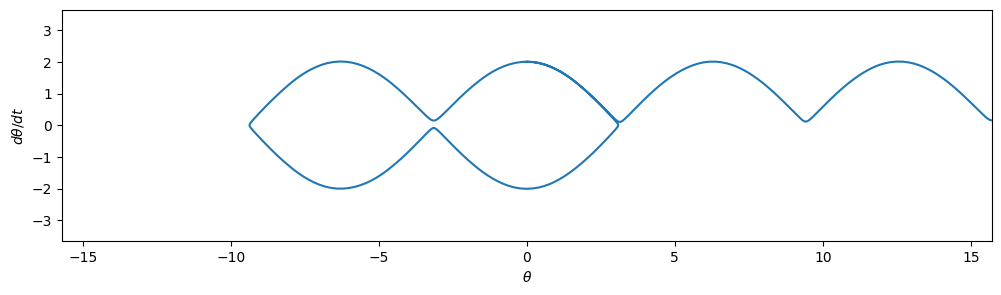

In [92]:
def rigid_pendulum_ode(t, y, omega_0=1):
 theta, ang_vel = y # unpacks y=[theta, ang_vel]
 dtheta_dt = ang_vel # define first derivative
 d2theta_dt2 = - omega_0 ** 2 * np.sin(theta) # define second derivative
 dy_dt = [dtheta_dt, d2theta_dt2] # define derivative of state variable
 return dy_dt

# Define the initial conditions, input parameters, and the time span
# initial conditions
theta_0 = 0
ang_vel_0 = 2
y_0 = [theta_0, ang_vel_0]

# input parameters
omega_0 = 1 # natural frequency

# time span
t_initial = 0
t_final = 100
t_span = [t_initial, t_final]

# solve differential equation
solution = solve_ivp(rigid_pendulum_ode, t_span, y_0, args=(omega_0,),dense_output=True) #rk45


# create list for plotting our solution
n_steps = 1000
t_plot = np.linspace(t_initial, t_final, n_steps)
theta_plot = solution.sol(t_plot)[0]
ang_vel_plot = solution.sol(t_plot)[1]

# plot the temporal evolution
plt.figure(figsize=(10,2))
plt.plot(t_plot, theta_plot)
plt.xlabel("time")
plt.ylabel("$\\theta$")
plt.xlim([0, 100])
plt.ylim(- 5 * np.pi, 5 * np.pi)
plt.show()

# plot the phase portrait
plt.figure(figsize=(12,3))
plt.plot(theta_plot, ang_vel_plot)
plt.xlabel("$\\theta$")
plt.ylabel("$d\\theta/dt$")
plt.xlim(- 5 * np.pi, 5 * np.pi)
plt.ylim(- np.pi - 0.5, np.pi + 0.5)
plt.show()


### to get a solution i used the RK45 method it works the same as the solution line in my code

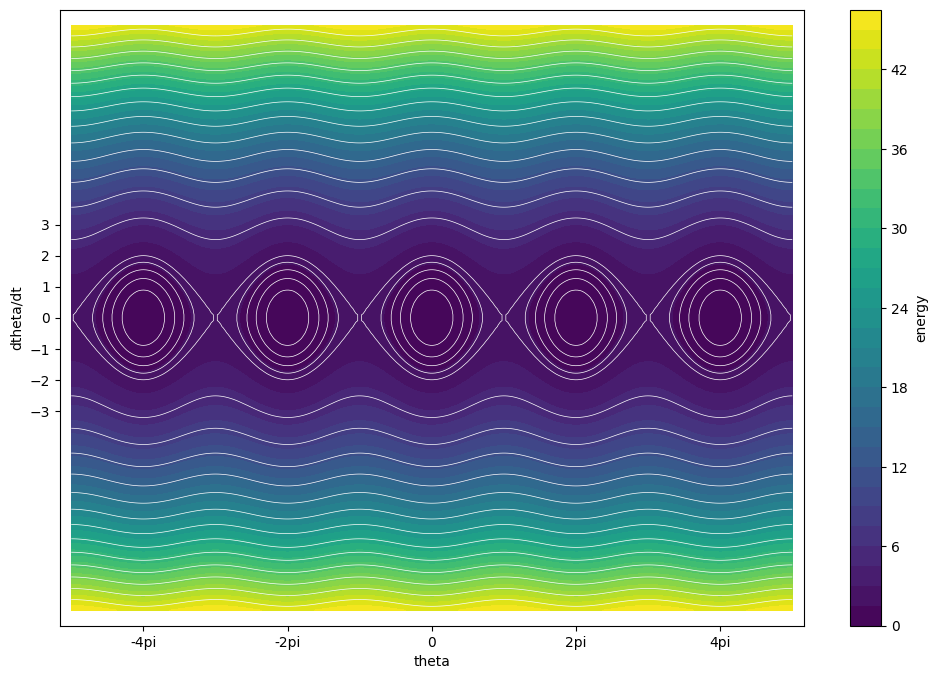

In [75]:
import numpy as np # Imports the NumPy
import matplotlib.pyplot as plt # Imports the plotting

def rigid_pendulum_energy(theta, ang_vel, omega_0=1, moment_of_inertia=1): # Defines a function
    energy = 0.5 * moment_of_inertia * ang_vel**2 + moment_of_inertia * omega_0**2 * (1 - np.cos(theta)) # Calculates the energy using the given formula
    return energy # Returns the calculated energy

theta_list = np.linspace(-5 * np.pi, 5 * np.pi, 300) # Creates an array of theta values
ang_vel_list = np.linspace(-3 * np.pi, 3 * np.pi, 100) # Creates an array of angular velocity values

theta_mesh, ang_vel_mesh = np.meshgrid(theta_list, ang_vel_list) # Creates a meshgrid from theta and angular velocity lists
energy_mesh = rigid_pendulum_energy(theta_mesh, ang_vel_mesh) # Calculates the energy for each point in the meshgrid

low_levels = np.linspace(0, 2, 5, endpoint=False) # Defines lower energy levels
high_levels = np.linspace(2, energy_mesh.max(), 15) # Defines higher energy levels
levels = np.concatenate((low_levels, high_levels)) # Combines lower and higher energy levels

x_lim = [-5 * np.pi - 0.5, 5 * np.pi + 0.5] # Defines x-axis limits for the plot
y_lim = [-3 * np.pi - 0.5, 3 * np.pi + 0.5] # Defines y-axis limits for the plot
x_ticks = np.array([-4, -2, 0, 2, 4]) * np.pi # Defines x-axis ticks
x_tick_labels = ['-4pi', '-2pi', '0', '2pi', '4pi'] # Defines labels for x-axis ticks

plt.figure(figsize=(12, 3))
contours = plt.contourf(theta_mesh, ang_vel_mesh, energy_mesh, levels=30, cmap='viridis') # Creates filled contours
plt.contour(theta_mesh, ang_vel_mesh, energy_mesh, levels=levels, colors='white', linewidths=0.5) # Adds contour lines
#plt.plot(theta_plot(0), ang_vel_plot[1], label='rigid pendulum', color='red', linewidth=0.5)
plt.colorbar(contours, label='energy') # Adds a colorbar to the plot
plt.xlabel('theta') # Sets the label for the x-axis
plt.ylabel('dtheta/dt') # Sets the label for the y-axis
plt.xticks(x_ticks, x_tick_labels) # Sets the x-axis ticks and labels
plt.yticks(range(-3, 4, 1)) # Sets the y-axis ticks
plt.xlim(x_lim) # Sets the x-axis limits
plt.ylim(y_lim) # Sets the y-axis limits
plt.show() # Displays the plot


## the middle looks similar to the phase portrait on problem 2, super cool looking though!